<a href="https://colab.research.google.com/github/jayaramanp/cNLP4QoL/blob/dev/cnlp4qol_workbook2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Open Colab notebook
# Run setup cell to install dependencies:
#!pip install transformers datasets huggingface_hub torch scikit-learn spacy
#!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 53.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install nbstripout

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
import spacy
spacy.load('en_core_web_md')

In [1]:
!git clone https://github.com/drmuskangarg/MultiWD.git
%cd MultiWD/
!ls

Cloning into 'MultiWD'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 31 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 762.36 KiB | 5.41 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/MultiWD
README.md  src.ipynb  test_data.csv  train_data.csv


In [2]:
import pandas as pd
train_df = pd.read_csv("train_data.csv")
train_df

,text,Spiritual,Physical,Intellectual,Social,Vocational,Emotional
0,I feel like my life is spiraling downwards get...,0,0,0,1,0,1
1,I say sorry way too much. I get things said to...,0,0,0,0,0,1
2,It's like I'm always sad because I don't know ...,0,1,0,1,0,0
3,You know this feeling when there are people ar...,0,0,0,1,0,0
4,"A few months ago (possibly more, my perception...",0,1,0,1,0,0
...,...,...,...,...,...,...,...
2619,I've had this since I was a kid. When I'm goin...,0,0,0,0,0,1
2620,Ive always been denying that I might have depr...,0,0,0,0,0,1
2621,I've talked with her for over a year. I develo...,0,1,0,1,0,1
2622,"It will get better for you, the person with mo...",0,0,0,1,0,1


In [3]:
test_df = pd.read_csv("test_data.csv")
test_df['text']

,text
0,I don‚Äôt understand how I‚Äôm feeling and all...
1,I hate every single thing about myself and I d...
2,"So today in particular was a very bad day, I f..."
3,My dad has had a long history of cheating on m...
4,I'm not sure which is worse: to be completely ...
...,...
652,Why does everyone think that it's just a tempo...
653,I hate myself so much It hurts I hate my body ...
654,I've been lying here for hours just doing noth...
655,"Married to a great guy, two great kids, a job ..."


In [4]:
test_df

,text,Spiritual,Physical,Intellectual,Social,Vocational,Emotional
0,I don‚Äôt understand how I‚Äôm feeling and all...,0,0,0,1,1,1
1,I hate every single thing about myself and I d...,0,0,0,1,0,0
2,"So today in particular was a very bad day, I f...",0,0,0,1,0,1
3,My dad has had a long history of cheating on m...,0,1,0,1,1,1
4,I'm not sure which is worse: to be completely ...,0,0,0,1,0,0
...,...,...,...,...,...,...,...
652,Why does everyone think that it's just a tempo...,0,0,0,1,0,1
653,I hate myself so much It hurts I hate my body ...,0,0,0,1,0,1
654,I've been lying here for hours just doing noth...,0,1,1,0,0,0
655,"Married to a great guy, two great kids, a job ...",0,1,1,1,1,1


# Rule-based tagging

In [ ]:
### qol lexicons
import re
from collections import defaultdict

# Define QoL lexicons per domain
qol_lexicons = {
    "Fatigue": [
        "tired", "exhausted", "fatigue", "energy", "stamina",
        "lethargic", "drained", "wiped out"
    ],
    "Emotional Well-Being": [
        "sad", "depressed", "anxious", "anxious", "worried", "stressed",
        "happy", "content", "mood", "emotions", "crying"
    ],
    "Physical Well-Being": [
        "pain", "ache", "hurt", "sore", "disability", "function",
        "mobility", "strength", "weakness", "ill"
    ],
    "Sleep Quality": [
        "sleep", "insomnia", "restless", "nightmare", "tiredness",
        "fatigue", "awake", "doze", "nap"
    ],
    "Social Functioning": [
        "friend", "family", "social", "alone", "lonely", "isolation",
        "relationship", "partner", "group", "communicate", "interact"
    ],
    "Activities of Daily Living": [
        "cooking", "cleaning", "dressing", "bathing", "shower",
        "walk", "exercise", "work", "activity", "task", "chore"
    ],
    "Pain": [
        "pain", "ache", "hurt", "sore", "discomfort", "cramp",
        "migraine", "headache", "arthritis", "injury"
    ]
}

In [ ]:
def rule_based_tagging(text):
    """Simple rule-based QoL tagging"""
    text_lower = text.lower()
    labels = []

    for domain, keywords in qol_lexicons.items():
        if any(kw in text_lower for kw in keywords):
            labels.append(domain)

    return labels

In [ ]:
# Test on sample turns
example_turns = [
    "[PATIENT]: I've been so tired lately and can't sleep.",
    "[CLINICIAN]: How long has this been going on?",
    "[PATIENT]: About two weeks. My legs also hurt when I walk.",
]


In [ ]:
### predict tags
for turn in example_turns:
    labels = rule_based_tagging(turn)
    print(f"Turn: {turn[:50]}...\nLabels: {labels}\n")

Turn: [PATIENT]: I've been so tired lately and can't sle...
Labels: ['Fatigue', 'Sleep Quality']

Turn: [CLINICIAN]: How long has this been going on?...
Labels: []

Turn: [PATIENT]: About two weeks. My legs also hurt when...
Labels: ['Physical Well-Being', 'Activities of Daily Living', 'Pain']



In [ ]:
qol_domains = [col for col in train_df.columns if col != 'text']
print("Extracted QoL Domains:", qol_domains)

Extracted QoL Domains: ['Spiritual', 'Physical', 'Intellectual', 'Social', 'Vocational', 'Emotional']


In [ ]:
qol_lexicons_from_df = {domain: [] for domain in qol_domains}
print("qol_lexicons_from_df created:", qol_lexicons_from_df)

qol_lexicons_from_df created: {'Spiritual': [], 'Physical': [], 'Intellectual': [], 'Social': [], 'Vocational': [], 'Emotional': []}


In [ ]:
import string
import spacy

nlp = spacy.load('en_core_web_md', disable=['parser', 'ner']) # Re-loading with disabled components for efficiency if not already done this way

def preprocess_text(text):
    """Preprocesses text by converting to lowercase, removing punctuation, tokenizing, lemmatizing, and filtering stopwords."""
    lower_text = text.lower()
    doc = nlp(lower_text)

    cleaned_tokens = [
        token.lemma_ for token in doc
        if not token.is_punct and not token.is_stop and token.is_alpha
    ]

    return cleaned_tokens

print("The 'preprocess_text' function has been defined.")

The 'preprocess_text' function has been defined.


In [ ]:
domain_corpora = {}

for domain in qol_domains:
    # Filter train_df for rows where the current domain's column has a value of 1
    filtered_df = train_df[train_df[domain] == 1]

    # Apply preprocess_text to the 'text' column and flatten the list of tokens
    all_tokens_for_domain = []
    for text in filtered_df['text']:
        all_tokens_for_domain.extend(preprocess_text(text))

    # Join the tokens to form a single corpus string for the domain
    domain_corpora[domain] = ' '.join(all_tokens_for_domain)

print("Generated corpora for each QoL domain:")
for domain, corpus_text in domain_corpora.items():
    print(f"\nDomain: {domain}")
    print(f"Corpus snippet: {corpus_text[:500]}...") # Print a snippet for brevity

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.8, # Ignore terms that appear in more than 80% of documents (domains)
    min_df=1,   # Consider terms that appear in at least 1 document (domain)
    ngram_range=(1, 1) # Only consider single words
)

# Fit and transform the domain corpora. The keys of domain_corpora are the domain names
# and the values are the corpus strings. TfidfVectorizer expects a list of documents.
corpus_list = [domain_corpora[domain] for domain in qol_domains]
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_list)

feature_names = tfidf_vectorizer.get_feature_names_out()

# Extract top N keywords for each domain based on TF-IDF scores
num_keywords = 15 # Define the number of top keywords to extract

for i, domain in enumerate(qol_domains):
    # Get TF-IDF scores for the current domain
    tfidf_scores = tfidf_matrix[i].toarray().flatten()

    # Create a dictionary of words and their TF-IDF scores
    word_scores = dict(zip(feature_names, tfidf_scores))

    # Sort words by TF-IDF score in descending order and select top N
    # Filter out generic stopwords again, if any made it through TFIDF (less likely with max_df)
    top_domain_keywords = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)

    # Select distinctive words, ensuring they are not generic and have a meaningful length
    selected_keywords = []
    for word, score in top_domain_keywords:
        if word not in generic_stopwords and len(word) > 2 and score > 0:
            selected_keywords.append(word)
        if len(selected_keywords) >= num_keywords:
            break

    qol_lexicons_from_df[domain] = selected_keywords

print(f"Updated qol_lexicons_from_df with top {num_keywords} TF-IDF keywords per domain:")
for domain, keywords in qol_lexicons_from_df.items():
    print(f"  {domain}: {keywords}")

Updated qol_lexicons_from_df with top 15 TF-IDF keywords per domain:
  Spiritual: ['shackle', 'gray', 'afterlife', 'forth', 'politician', 'immortality', 'percieve', 'realisation', 'refreshment', 'cloud', 'image', 'nowadays', 'dinosaur', 'flicker', 'focused']
  Physical: ['prescribe', 'effexor', 'celexa', 'wellbutrin', 'sober', 'seizure', 'masturbate', 'ssri', 'citalopram', 'doc', 'scary', 'curious', 'sertraline', 'autism', 'prescription']
  Intellectual: ['motivate', 'peer', 'biasd', 'fxxk', 'project', 'shelter', 'dish', 'tel', 'chapter', 'assignment', 'professor', 'teenage', 'flunk', 'possess', 'revise']
  Social: ['bar', 'sober', 'outcast', 'snapchat', 'biasd', 'breakup', 'marriage', 'respect', 'responsibility', 'scary', 'teenage', 'throat', 'center', 'friendly', 'identity']
  Vocational: ['bar', 'motivate', 'retail', 'xmas', 'cash', 'emergency', 'fund', 'payment', 'shelter', 'sober', 'store', 'becouse', 'breaking', 'possess', 'coast']
  Emotional: ['scary', 'curious', 'bar', 'rage',

In [ ]:
print("Current qol_lexicons_from_df for review:")
for domain, keywords in qol_lexicons_from_df.items():
    print(f"  {domain}: {keywords}")

Current qol_lexicons_from_df for review:
  Spiritual: ['shackle', 'gray', 'afterlife', 'forth', 'politician', 'immortality', 'percieve', 'realisation', 'refreshment', 'cloud', 'image', 'nowadays', 'dinosaur', 'flicker', 'focused']
  Physical: ['prescribe', 'effexor', 'celexa', 'wellbutrin', 'sober', 'seizure', 'masturbate', 'ssri', 'citalopram', 'doc', 'scary', 'curious', 'sertraline', 'autism', 'prescription']
  Intellectual: ['motivate', 'peer', 'biasd', 'fxxk', 'project', 'shelter', 'dish', 'tel', 'chapter', 'assignment', 'professor', 'teenage', 'flunk', 'possess', 'revise']
  Social: ['bar', 'sober', 'outcast', 'snapchat', 'biasd', 'breakup', 'marriage', 'respect', 'responsibility', 'scary', 'teenage', 'throat', 'center', 'friendly', 'identity']
  Vocational: ['bar', 'motivate', 'retail', 'xmas', 'cash', 'emergency', 'fund', 'payment', 'shelter', 'sober', 'store', 'becouse', 'breaking', 'possess', 'coast']
  Emotional: ['scary', 'curious', 'bar', 'rage', 'specifically', 'crying', '

In [ ]:
### save qol_lexicon_from_df to csv
import csv
import pandas as pd

# Convert the dictionary to a pandas DataFrame.
# Since each value in the dictionary is a list of keywords, we can create a DataFrame where each column is a domain and its values are the keywords.
# To handle lists of different lengths, we can use `pd.DataFrame.from_dict` and transpose.

# First, ensure all lists have the same length or handle NaNs appropriately if they don't
# A simpler approach for saving key-value pairs where values are lists is to save each domain's keywords as a separate column.

df_to_save = pd.DataFrame.from_dict(qol_lexicons_from_df, orient='index').transpose()

df_to_save.to_csv('qol_lexicons_from_df_to_review.csv', index=False)

print("qol_lexicons_from_df has been saved to 'qol_lexicons_from_df_to_review.csv' for review.")

qol_lexicons_from_df has been saved to 'qol_lexicons_from_df_to_review.csv' for review.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, f1_score

# Predict on test set
y_pred = [rule_based_tagging(test_df["text"])]
y_true = [qol_lexicons_from_df[""] for turn in test_df]

# Multi-label evaluation
# Flatten to binary matrix for per-domain evaluation
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
y_true_bin = mlb.fit_transform(y_true)
y_pred_bin = mlb.transform(y_pred)

# Per-domain F1
for i, domain in enumerate(mlb.classes_):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_bin[:, i], y_pred_bin[:, i], average=None
    )
    print(f"{domain}: P={p[1]:.3f}, R={r[1]:.3f}, F1={f1[1]:.3f}")

# Macro F1
macro_f1 = f1_score(y_true_bin, y_pred_bin, average="macro")
print(f"\nMacro F1: {macro_f1:.3f}")

In [ ]:
def rule_based_tagging_from_df(text):
    """Identifies relevant QoL domains based on keywords in qol_lexicons_from_df."""
    text_lower = text.lower()
    labels = []

    for domain, keywords in qol_lexicons_from_df.items():
        # Check if any keyword from the current domain is present in the text
        if any(keyword in text_lower for keyword in keywords):
            labels.append(domain)

    return labels


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.preprocessing import MultiLabelBinarizer

# Generate predicted labels (y_pred_raw) using the rule_based_tagging_from_df function
y_pred_raw = [rule_based_tagging_from_df(text) for text in test_df['text']]

# Extract true labels (y_true_bin) directly from test_df as a binary numpy array.
# This is already in the format expected by sklearn's evaluation metrics for y_true.
y_true_bin = test_df[qol_domains].values

# Initialize MultiLabelBinarizer with all possible QoL domains to ensure consistent encoding
# for the predicted labels and alignment with y_true_bin.
mlb = MultiLabelBinarizer(classes=qol_domains)

# Fit the MultiLabelBinarizer with the predicted raw labels to learn the classes present.
# This is necessary before calling transform.
mlb.fit(y_pred_raw)

# Transform the raw predicted labels (lists of strings) into a binary matrix.
y_pred_bin = mlb.transform(y_pred_raw)

print("Evaluation Results:")
# Per-domain F1, Precision, and Recall
for i, domain in enumerate(qol_domains):
    p, r, f1, _ = precision_recall_fscore_support(y_true_bin[:, i], y_pred_bin[:, i], average='binary', zero_division=0)
    print(f"  {domain}: P={p:.3f}, R={r:.3f}, F1={f1:.3f}")

# Macro F1
macro_f1 = f1_score(y_true_bin, y_pred_bin, average="macro", zero_division=0)
print(f"\nMacro F1: {macro_f1:.3f}")

print("Multi-label evaluation complete, including per-domain precision, recall, and F1-score, and overall macro F1-score.")

Evaluation Results:
  Spiritual: P=0.143, R=0.054, F1=0.078
  Physical: P=0.614, R=0.136, F1=0.223
  Intellectual: P=0.223, R=0.328, F1=0.265
  Social: P=0.743, R=0.131, F1=0.223
  Vocational: P=0.333, R=0.237, F1=0.277
  Emotional: P=0.582, R=0.196, F1=0.294

Macro F1: 0.227
Multi-label evaluation complete, including per-domain precision, recall, and F1-score, and overall macro F1-score.


# Transformer-based tagging pipeline

In [5]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

In [6]:
import pandas as pd
from datasets import Dataset

label_cols = [
    "Spiritual",
    "Physical",
    "Intellectual",
    "Social",
    "Vocational",
    "Emotional"
]

df = pd.read_csv("train_data.csv")

# make sure labels are float
df[label_cols] = df[label_cols].astype(float)

# create label vector
df["labels"] = df[label_cols].values.tolist()

dataset = Dataset.from_pandas(df)

In [7]:
from transformers import AutoTokenizer

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    tokenized = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    tokenized["labels"] = example["labels"]
    return tokenized

dataset = dataset.map(tokenize_function)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2624 [00:00<?, ? examples/s]

In [8]:
sample = dataset[0]
print(sample["labels"])
print(sample["labels"].dtype)

tensor([0., 0., 0., 1., 0., 1.])
torch.float32


In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    problem_type="multi_label_classification"
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits))
    preds = (probs > 0.5).int().numpy()

    return {
        "micro_f1": f1_score(labels, preds, average="micro"),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "precision": precision_score(labels, preds, average="micro"),
        "recall": recall_score(labels, preds, average="micro")
    }

In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=4,
    #evaluation_strategy="epoch",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.386537


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=656, training_loss=0.36293105962799815, metrics={'train_runtime': 583.2778, 'train_samples_per_second': 17.995, 'train_steps_per_second': 1.125, 'total_flos': 1380856409358336.0, 'train_loss': 0.36293105962799815, 'epoch': 4.0})

In [12]:
trainer.save_model("./best_qol_roberta_model")
tokenizer.save_pretrained("./best_qol_roberta_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_qol_roberta_model/tokenizer_config.json',
 './best_qol_roberta_model/tokenizer.json')

In [13]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report

# -----------------------------
# 1. Define label columns
# -----------------------------
label_cols = [
    "Spiritual",
    "Physical",
    "Intellectual",
    "Social",
    "Vocational",
    "Emotional"
]

# -----------------------------
# 2. Load test dataset
# -----------------------------
df_test = pd.read_csv("test_data.csv")

# If true labels exist in test set, keep them for evaluation
has_labels = all(col in df_test.columns for col in label_cols)

if has_labels:
    df_test[label_cols] = df_test[label_cols].astype(float)
    df_test["labels"] = df_test[label_cols].values.tolist()

test_dataset = Dataset.from_pandas(df_test)

# -----------------------------
# 3. Tokenize test dataset
# -----------------------------
def tokenize_function(example):
    enc = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    if "labels" in example:
        enc["labels"] = [float(x) for x in example["labels"]]
    return enc

test_dataset = test_dataset.map(tokenize_function)

if has_labels:
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
else:
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

# -----------------------------
# 4. Predict on test set
# -----------------------------
pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
probs = torch.sigmoid(torch.tensor(logits)).numpy()

# default threshold = 0.5
preds = (probs >= 0.5).astype(int)

# -----------------------------
# 5. Save predictions
# -----------------------------
df_pred = df_test.copy()

for i, col in enumerate(label_cols):
    df_pred[f"{col}_prob"] = probs[:, i]
    df_pred[f"{col}_pred"] = preds[:, i]

df_pred.to_csv("test_predictions.csv", index=False)

print("Saved predictions to: test_predictions.csv")
print(df_pred[[ "text" ] + [f"{c}_pred" for c in label_cols]].head())

Map:   0%|          | 0/657 [00:00<?, ? examples/s]

Saved predictions to: test_predictions.csv
                                                text  Spiritual_pred  \
0  I don‚Äôt understand how I‚Äôm feeling and all...               0   
1  I hate every single thing about myself and I d...               0   
2  So today in particular was a very bad day, I f...               0   
3  My dad has had a long history of cheating on m...               0   
4  I'm not sure which is worse: to be completely ...               0   

   Physical_pred  Intellectual_pred  Social_pred  Vocational_pred  \
0              0                  0            1                1   
1              0                  0            1                0   
2              0                  0            1                0   
3              0                  0            1                1   
4              0                  0            1                0   

   Emotional_pred  
0               1  
1               1  
2               0  
3               0  
4        

In [14]:
# -----------------------------
# 6. Evaluate if true labels exist
# -----------------------------
if has_labels:
    y_true = df_test[label_cols].values.astype(int)
    y_pred = preds
    y_prob = probs

    print("Micro F1:", f1_score(y_true, y_pred, average="micro"))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print("Micro Precision:", precision_score(y_true, y_pred, average="micro", zero_division=0))
    print("Micro Recall:", recall_score(y_true, y_pred, average="micro", zero_division=0))

    try:
        print("Macro AUROC:", roc_auc_score(y_true, y_prob, average="macro"))
        print("Micro AUROC:", roc_auc_score(y_true, y_prob, average="micro"))
    except ValueError as e:
        print("AUROC could not be computed:", e)

    # Per-label metrics
    for i, col in enumerate(label_cols):
        print(f"\n===== {col} =====")
        print(classification_report(
            y_true[:, i],
            y_pred[:, i],
            target_names=[f"not_{col}", col],
            zero_division=0
        ))

Micro F1: 0.7364864864864865
Macro F1: 0.5964052222721401
Micro Precision: 0.755632582322357
Micro Recall: 0.7182866556836903
Macro AUROC: 0.8456376580124672
Micro AUROC: 0.9071620439931011

===== Spiritual =====
               precision    recall  f1-score   support

not_Spiritual       0.94      1.00      0.97       620
    Spiritual       0.00      0.00      0.00        37

     accuracy                           0.94       657
    macro avg       0.47      0.50      0.49       657
 weighted avg       0.89      0.94      0.92       657


===== Physical =====
              precision    recall  f1-score   support

not_Physical       0.86      0.90      0.88       459
    Physical       0.75      0.67      0.71       198

    accuracy                           0.83       657
   macro avg       0.81      0.79      0.79       657
weighted avg       0.83      0.83      0.83       657


===== Intellectual =====
                  precision    recall  f1-score   support

not_Intellectual    

In [15]:
df_submission = df_test[["text"]].copy()

for i, col in enumerate(label_cols):
    df_submission[col] = preds[:, i]

df_submission.to_csv("test_predicted_labels_only.csv", index=False)
print("Saved label-only predictions to: test_predicted_labels_only.csv")

Saved label-only predictions to: test_predicted_labels_only.csv


# Testing the model on patient-provider conversation

Device: cuda


100%|██████████| 9.59k/9.59k [00:00<00:00, 23.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/neelghoshal/therapist-patient-conversation-dataset/versions/1

Files found:
- /root/.cache/kagglehub/datasets/neelghoshal/therapist-patient-conversation-dataset/versions/1/intents.json

Loaded: /root/.cache/kagglehub/datasets/neelghoshal/therapist-patient-conversation-dataset/versions/1/intents.json | shape=(13, 1)

Selected file for inference: /root/.cache/kagglehub/datasets/neelghoshal/therapist-patient-conversation-dataset/versions/1/intents.json
Shape: (13, 1)

Columns:
['intents']

Text source used: ALL_OBJECT_COLUMNS
Usable rows: 13

Example combined text:

{'tag': 'greetings', 'patterns': ['hello', 'hey', 'hi', 'good day', 'greetings', "what's up?", 'how is it going'], 'resonses': ['Hello! How are you today!', "Hey! What's up", 'Hey, How are you feeling today']}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loaded saved model from: ./best_qol_roberta_model
Model num_labels: 6

Prediction array shape: (13, 6)

Saved full predictions to: ./kaggle_conversation_qol_outputs/therapist_patient_qol_predictions_full.csv
Saved label-only predictions to: ./kaggle_conversation_qol_outputs/therapist_patient_qol_predicted_labels_only.csv

Predicted label prevalence:
          label  predicted_positive_count  predicted_positive_rate  \
3        Social                        13                 1.000000   
5     Emotional                        11                 0.846154   
1      Physical                         4                 0.307692   
2  Intellectual                         1                 0.076923   
4    Vocational                         1                 0.076923   
0     Spiritual                         0                 0.000000   

   mean_probability  
3          0.894140  
5          0.572275  
1          0.324791  
2          0.128560  
4          0.075875  
0          0.048530  

P

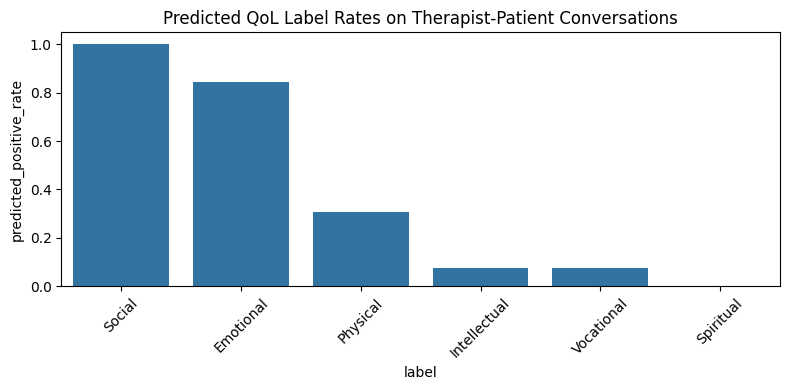

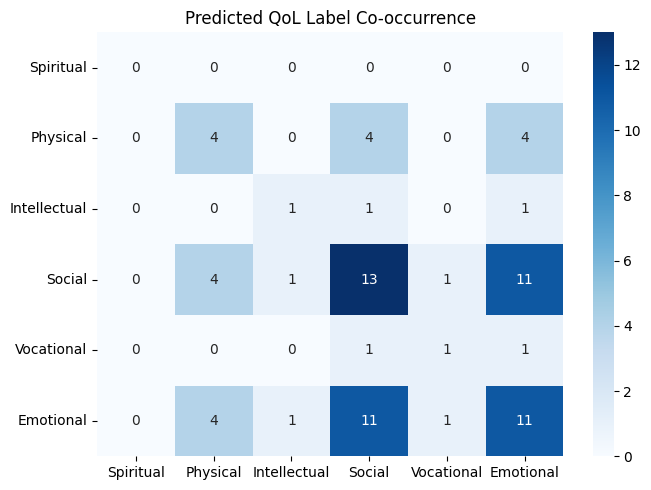


Preview of predictions:


,combined_text,Spiritual_pred,Physical_pred,Intellectual_pred,Social_pred,Vocational_pred,Emotional_pred
0,"{'tag': 'greetings', 'patterns': ['hello', 'he...",0,0,0,1,0,0
1,"{'tag': 'goodbye', 'patterns': ['cya', 'see yo...",0,0,0,1,0,0
2,"{'tag': 'self-esteem-A', 'patterns': [""How do ...",0,0,1,1,0,1
3,"{'tag': 'self-esteem-B', 'patterns': ['How can...",0,0,0,1,0,1
4,"{'tag': 'relationship-b', 'patterns': ['Why do...",0,0,0,1,0,1
5,"{'tag': 'relationship-a', 'patterns': ['Why do...",0,0,0,1,0,1
6,"{'tag': 'angermanagement-a', 'patterns': ['How...",0,0,0,1,0,1
7,"{'tag': 'angermanagement-b', 'patterns': [""We'...",0,1,0,1,0,1
8,"{'tag': 'domesticviolence', 'patterns': ['How ...",0,1,0,1,0,1
9,"{'tag': 'griefandloss', 'patterns': ['I just l...",0,0,0,1,0,1



Done. Review these files in: ./kaggle_conversation_qol_outputs
- therapist_patient_qol_predictions_full.csv
- therapist_patient_qol_predicted_labels_only.csv
- predicted_label_prevalence.csv
- predicted_label_cooccurrence.csv
- top_high_confidence_examples_per_label.csv
- most_uncertain_examples_for_manual_review.csv
- random_100_examples_for_manual_review.csv


In [16]:
# ============================================================
# Install packages
# ============================================================
# !pip -q install kagglehub transformers torch pandas numpy matplotlib seaborn openpyxl

# ============================================================
# Imports
# ============================================================
import os
import glob
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# ============================================================
# Configuration
# ============================================================
MODEL_DIR = "./best_qol_roberta_model"
OUTPUT_DIR = "./kaggle_conversation_qol_outputs"
MAX_LEN = 256
BATCH_SIZE = 16

# use the threshold you want for transfer inference
# if you did not tune one, start with 0.35 instead of 0.50
THRESHOLD = 0.35

LABEL_COLS = [
    "Spiritual",
    "Physical",
    "Intellectual",
    "Social",
    "Vocational",
    "Emotional"
]

FINAL_TEXT_COL = "combined_text"

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# Download Kaggle dataset
# ============================================================
path = kagglehub.dataset_download("neelghoshal/therapist-patient-conversation-dataset")
print("Path to dataset files:", path)

# ============================================================
# Find files in dataset folder
# ============================================================
candidate_files = []
for ext in ["*.csv", "*.tsv", "*.json", "*.jsonl", "*.xlsx"]:
    candidate_files.extend(glob.glob(os.path.join(path, "**", ext), recursive=True))

print("\nFiles found:")
for f in candidate_files:
    print("-", f)

if len(candidate_files) == 0:
    raise FileNotFoundError("No CSV/TSV/JSON/JSONL/XLSX files were found in the Kaggle dataset folder.")

# ============================================================
# Generic loader
# ============================================================
def load_table(file_path):
    if file_path.endswith(".csv"):
        return pd.read_csv(file_path)
    elif file_path.endswith(".tsv"):
        return pd.read_csv(file_path, sep="\t")
    elif file_path.endswith(".xlsx"):
        return pd.read_excel(file_path)
    elif file_path.endswith(".json"):
        try:
            return pd.read_json(file_path)
        except:
            with open(file_path, "r") as f:
                data = json.load(f)
            return pd.json_normalize(data)
    elif file_path.endswith(".jsonl"):
        rows = []
        with open(file_path, "r") as f:
            for line in f:
                rows.append(json.loads(line))
        return pd.json_normalize(rows)
    else:
        raise ValueError(f"Unsupported file type: {file_path}")

# ============================================================
# Load all readable files and choose the largest table
# ============================================================
loaded_tables = []
for f in candidate_files:
    try:
        temp_df = load_table(f)
        loaded_tables.append((f, temp_df))
        print(f"\nLoaded: {f} | shape={temp_df.shape}")
    except Exception as e:
        print(f"\nCould not load {f}: {e}")

if len(loaded_tables) == 0:
    raise RuntimeError("None of the files could be loaded.")

loaded_tables = sorted(
    loaded_tables,
    key=lambda x: x[1].shape[0] * max(1, x[1].shape[1]),
    reverse=True
)

selected_file, df = loaded_tables[0]
print("\nSelected file for inference:", selected_file)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# Build a conversation text column robustly
# ============================================================
single_text_candidates = [
    "text", "conversation", "dialogue", "dialog", "utterance",
    "content", "transcript", "message"
]

pair_candidates = [
    ("patient", "therapist"),
    ("patient_text", "therapist_text"),
    ("patient_message", "therapist_message"),
    ("user", "assistant"),
    ("speaker_1", "speaker_2"),
    ("input", "response"),
    ("prompt", "reply"),
    ("question", "answer")
]

text_source = None

# case 1: direct text column
for c in single_text_candidates:
    if c in df.columns:
        df[FINAL_TEXT_COL] = df[c].fillna("").astype(str)
        text_source = c
        break

# case 2: combine two dialogue columns
if FINAL_TEXT_COL not in df.columns:
    for c1, c2 in pair_candidates:
        if c1 in df.columns and c2 in df.columns:
            df[FINAL_TEXT_COL] = (
                "Patient: " + df[c1].fillna("").astype(str) +
                " Therapist: " + df[c2].fillna("").astype(str)
            )
            text_source = f"{c1} + {c2}"
            break

# case 3: concatenate all object columns
if FINAL_TEXT_COL not in df.columns:
    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    if len(object_cols) == 0:
        raise ValueError("Could not identify any text-like columns in the dataset.")
    df[FINAL_TEXT_COL] = df[object_cols].fillna("").astype(str).agg(" ".join, axis=1)
    text_source = "ALL_OBJECT_COLUMNS"

df[FINAL_TEXT_COL] = df[FINAL_TEXT_COL].fillna("").astype(str).str.strip()
df = df[df[FINAL_TEXT_COL] != ""].reset_index(drop=True)

print("\nText source used:", text_source)
print("Usable rows:", len(df))
print("\nExample combined text:\n")
print(df[FINAL_TEXT_COL].iloc[0][:1200])

# ============================================================
# Load saved tokenizer and saved model
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

print("\nLoaded saved model from:", MODEL_DIR)
print("Model num_labels:", model.config.num_labels)

if model.config.num_labels != len(LABEL_COLS):
    print("\nWARNING: model.num_labels does not match the 6 QoL labels.")
    print("Please confirm MODEL_DIR points to your QoL model.")

# ============================================================
# Inference dataset
# ============================================================
class ConversationInferenceDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, FINAL_TEXT_COL])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "text": text
        }

infer_ds = ConversationInferenceDataset(df, tokenizer, MAX_LEN)
infer_loader = DataLoader(infer_ds, batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# Predict
# ============================================================
all_probs = []
all_texts = []

with torch.no_grad():
    for batch in infer_loader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=ids, attention_mask=mask)
        logits = outputs.logits
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_texts.extend(batch["text"])

all_probs = np.vstack(all_probs)
all_preds = (all_probs >= THRESHOLD).astype(int)

print("\nPrediction array shape:", all_probs.shape)

# ============================================================
# Save full prediction file
# ============================================================
pred_df = df.copy()

for i, label in enumerate(LABEL_COLS):
    pred_df[f"{label}_prob"] = all_probs[:, i]
    pred_df[f"{label}_pred"] = all_preds[:, i]

full_pred_file = os.path.join(OUTPUT_DIR, "therapist_patient_qol_predictions_full.csv")
pred_df.to_csv(full_pred_file, index=False)

print("\nSaved full predictions to:", full_pred_file)

# ============================================================
# Save label-only file
# ============================================================
label_only_df = pd.DataFrame()
label_only_df[FINAL_TEXT_COL] = pred_df[FINAL_TEXT_COL]

for i, label in enumerate(LABEL_COLS):
    label_only_df[label] = all_preds[:, i]

label_only_file = os.path.join(OUTPUT_DIR, "therapist_patient_qol_predicted_labels_only.csv")
label_only_df.to_csv(label_only_file, index=False)

print("Saved label-only predictions to:", label_only_file)

# ============================================================
# Posthoc analysis 1: prevalence
# ============================================================
prevalence_df = pd.DataFrame({
    "label": LABEL_COLS,
    "predicted_positive_count": all_preds.sum(axis=0),
    "predicted_positive_rate": all_preds.mean(axis=0),
    "mean_probability": all_probs.mean(axis=0)
}).sort_values("predicted_positive_rate", ascending=False)

print("\nPredicted label prevalence:")
print(prevalence_df)

prevalence_df.to_csv(os.path.join(OUTPUT_DIR, "predicted_label_prevalence.csv"), index=False)

# ============================================================
# Posthoc analysis 2: co-occurrence matrix
# ============================================================
pred_binary_df = pd.DataFrame(all_preds, columns=LABEL_COLS)
cooccurrence_df = pred_binary_df.T.dot(pred_binary_df)

print("\nPredicted label co-occurrence matrix:")
print(cooccurrence_df)

cooccurrence_df.to_csv(os.path.join(OUTPUT_DIR, "predicted_label_cooccurrence.csv"))

# ============================================================
# Posthoc analysis 3: high-confidence examples per label
# ============================================================
top_examples = []

for i, label in enumerate(LABEL_COLS):
    tmp = pred_df[[FINAL_TEXT_COL, f"{label}_prob", f"{label}_pred"]].copy()
    tmp = tmp.sort_values(f"{label}_prob", ascending=False).head(25)
    tmp["label"] = label
    top_examples.append(tmp)

top_examples_df = pd.concat(top_examples, ignore_index=True)
top_examples_file = os.path.join(OUTPUT_DIR, "top_high_confidence_examples_per_label.csv")
top_examples_df.to_csv(top_examples_file, index=False)

print("\nSaved high-confidence examples to:", top_examples_file)

# ============================================================
# Posthoc analysis 4: uncertain examples for manual review
# ============================================================
# smaller value = closer to threshold = more uncertain
uncertainty_score = np.min(np.abs(all_probs - THRESHOLD), axis=1)

uncertain_df = pred_df.copy()
uncertain_df["uncertainty_score"] = uncertainty_score
uncertain_df = uncertain_df.sort_values("uncertainty_score", ascending=True).head(100)

uncertain_file = os.path.join(OUTPUT_DIR, "most_uncertain_examples_for_manual_review.csv")
uncertain_df.to_csv(uncertain_file, index=False)

print("Saved uncertain examples to:", uncertain_file)

# ============================================================
# Posthoc analysis 5: random review sample
# ============================================================
review_sample_df = pred_df.sample(min(100, len(pred_df)), random_state=42)
review_sample_file = os.path.join(OUTPUT_DIR, "random_100_examples_for_manual_review.csv")
review_sample_df.to_csv(review_sample_file, index=False)

print("Saved random review sample to:", review_sample_file)

# ============================================================
# Simple plots
# ============================================================
plt.figure(figsize=(8, 4))
sns.barplot(data=prevalence_df, x="label", y="predicted_positive_rate")
plt.xticks(rotation=45)
plt.title("Predicted QoL Label Rates on Therapist-Patient Conversations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(cooccurrence_df, annot=True, fmt="d", cmap="Blues")
plt.title("Predicted QoL Label Co-occurrence")
plt.tight_layout()
plt.show()

# ============================================================
# Quick preview
# ============================================================
preview_cols = [FINAL_TEXT_COL] + [f"{label}_pred" for label in LABEL_COLS]
print("\nPreview of predictions:")
display(pred_df[preview_cols].head(10))

print("\nDone. Review these files in:", OUTPUT_DIR)
print("- therapist_patient_qol_predictions_full.csv")
print("- therapist_patient_qol_predicted_labels_only.csv")
print("- predicted_label_prevalence.csv")
print("- predicted_label_cooccurrence.csv")
print("- top_high_confidence_examples_per_label.csv")
print("- most_uncertain_examples_for_manual_review.csv")
print("- random_100_examples_for_manual_review.csv")